# Дано

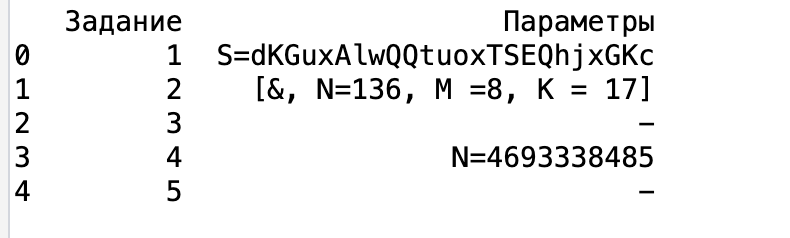

#Задача №1

In [ ]:
format ELF64

public _start

section '.data' writeable
    msg db 'dKGuxAlwQQtuoxTSEQhjxGKc', 10
    msg_len = $ - msg

section '.text' executable
_start:
    mov rsi, msg
    mov rdi, msg + msg_len - 2

reverse_loop:
    cmp rsi, rdi ; сравниваем девый и правый указатели
    jge print_result ; если указатели поменялись местами, то печатаем результат

    mov al, [rsi] ; меняем символы местами
    mov bl, [rdi]
    mov [rsi], bl
    mov [rdi], al

    inc rsi ; смещаем левый указатель вправо, а правый влево
    dec rdi
    jmp reverse_loop

print_result:
    mov rax, 1
    mov rdi, 1
    mov rsi, msg
    mov rdx, msg_len
    syscall

    mov rax, 60
    xor rdi, rdi
    syscall

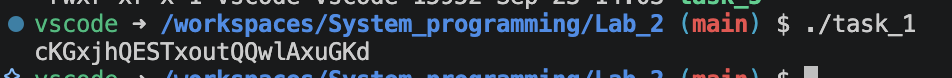

# Задача №2

In [ ]:
format ELF64

public _start

section ".data" writeable
    n = 136
    buffer db n dup ("&")
    newline db 10
    m = 8
    k = 17

section ".text" executable

loop_K:
    mov rax, 1 ; выводим m символов
    mov rdi, 1
    mov rsi, buffer
    mov rdx, m
    syscall

    mov rax, 1 ; выводим символ переноса строки
    mov rdi, 1
    mov rsi, newline
    mov rdx, 1
    syscall

    inc R8 ; увеличиваем счетчик количества выведенных строк и если надо возвращаемся в начало цикла
    cmp R8, k
    jl loop_K

    mov rax, 60
    xor rdi, rdi
    syscall

_start:
    mov R8, 0
    jmp loop_K

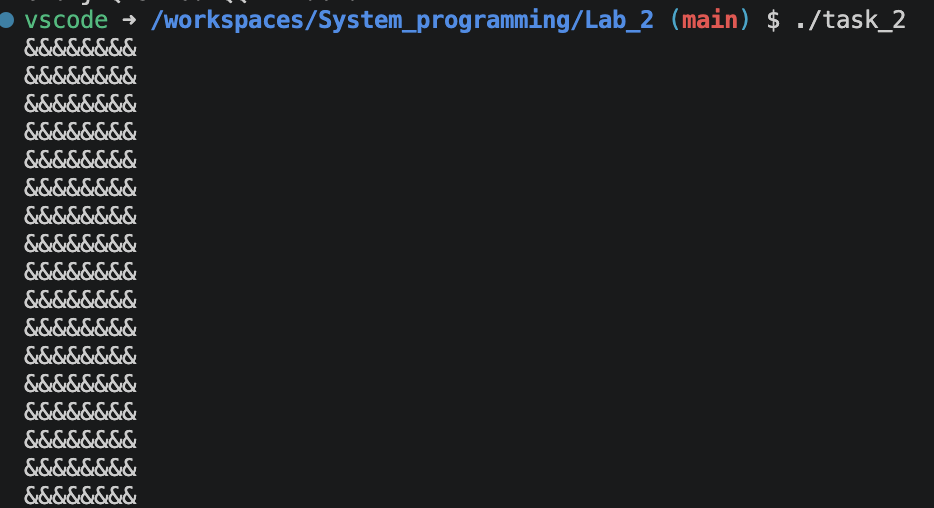

# Задача №3

In [ ]:
format ELF64

public _start

section ".data" writeable
    n = 136
    buffer db n dup ("&")
    newline db 10


section ".text" executable

; считать выведенные строки будем с еденицы, тогда в первой строке надо вывести 1 символ, во второй - 2 и т.д.
; То есть в n-ой строке надо вывести n символовб.

_start:
    mov R8, 1; счетчик выведенных строк
    mov R9, n; количество символов которые ещё не напечатанны
    _loop:
        mov rax, 1
        mov rdi, 1
        mov rsi, buffer
        mov rdx, R8
        syscall

        call end_line

        sub R9, R8

        inc R8
        cmp R8, R9
        jle _loop

    cmp R9,0 ; если после цикла остались не напечатанные символы, то печатаем их
    je exit

    mov rax, 1
    mov rdi, 1
    mov rsi, buffer
    mov rdx, R9
    syscall

    call end_line
    jmp exit

end_line: ; функция для вывода символа конца строки
    mov rax, 1
    mov rdi, 1
    mov rsi, newline
    mov rdx, 1
    syscall
    ret

exit:
    mov rax, 60
    xor rdi,rdi
    syscall

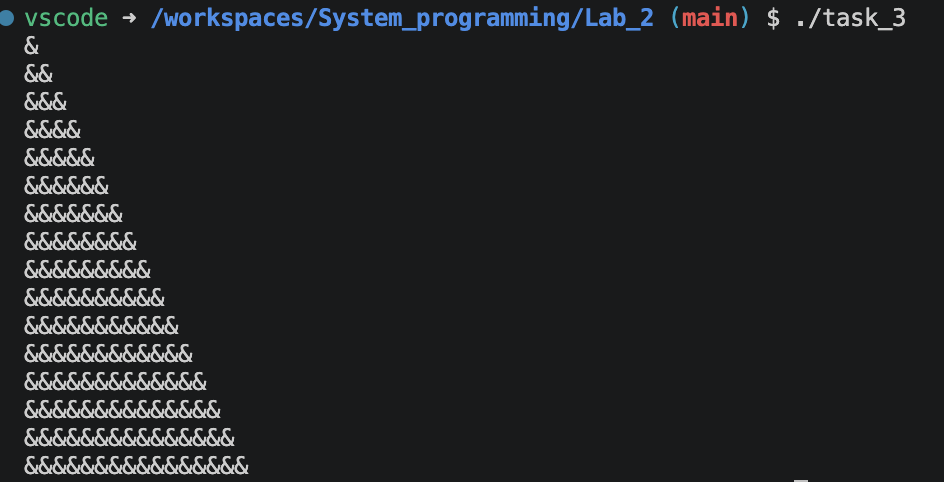

# Задача №4

In [ ]:
format ELF64

public _start

section ".data" writeable
    n = 4693338485
    buffer db 16

section ".text" executable

_start:
    mov R8, 0
    mov rax, n
    mov rdi, 10

    @@:; делим искомое число на 10 до тех пор, пока частное не станет равным нулю
      ;эта операция необходима что бы перевести число из двоичной системы счисления(СС) в дестеричную
      ;но остаткиот деления будем сумировать
        xor rdx,rdx
        div rdi
        add R8, rdx

        cmp rax, 0
        jg @b

    mov rax, R8
    call print_int

    mov rax, 60
    xor rdi, rdi
    syscall

print_int:;функция печатает значение регистра rax как целое беззнаковое число
    mov rsi, 0
    mov rdi, 10

    @@: ;принцип работы такой же как у предыдущего цикла, где переводилось число из одной СС в другую,
    ; но здесь будем записывать остатки в специальный буфер
        xor rdx, rdx
        div rdi
        add rdx, '0'
        mov [buffer + rsi], dl
        inc rsi

        cmp rax, 0
        jg @b

    mov [buffer + rsi], 10; в конец буфера добавим символ конца строки

  ; развернём буфер в обратном порядке, как в задании №1
    mov rdi, buffer
    add rdi, rsi
    dec rdi
    mov rsi, buffer

    @@:
    cmp rsi, rdi
    jge @f

    mov al, [rsi]
    mov bl, [rdi]
    mov [rsi], bl
    mov [rdi], al

    inc rsi
    dec rdi
    jmp @b
    @@:

    mov rax, 1
    mov rdi, 1
    mov rsi, buffer
    syscall
    ret

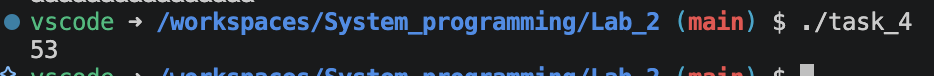

# Задача №5

In [ ]:
#include <stdio.h>

int main(void) {
    unsigned long long number = 4693338485;
    unsigned long long sum = 0;
    unsigned long long temp = number;

    while (temp > 0) {
        sum += temp % 10;
        temp /= 10;
    }

    printf("%llu\n", sum);

    return 0;
}

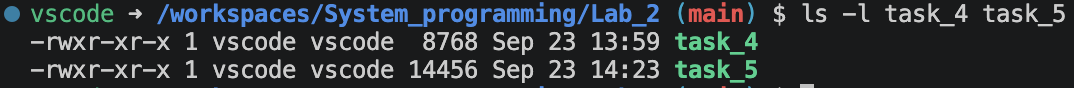